In [15]:
import chipwhisperer as cw
import chipwhisperer.common.results.glitch as glitch
import numpy as np
import time

# --- USER CONFIGURATION ---
# *** IMPORTANT:BITSTREAM PATH ***
BITSTREAM_FILEPATH = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit'

# Set a fixed key and plaintext for consistent testing
KEY = bytearray([0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6, 0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C])
PLAINTEXT = bytearray([0x5C, 0x69, 0x2F, 0x91, 0x03, 0xB2, 0x30, 0x29, 0x14, 0xD7, 0xE5, 0x55, 0xE4, 0xDC, 0xEE, 0x49])
EXPECTED_CIPHERTEXT = bytearray([0x06, 0xF3, 0x6A, 0x65, 0xE8, 0xA9, 0x9F, 0xF8, 0x90, 0x7B, 0x2E, 0x5E, 0x5D, 0xDD, 0x77, 0xDE])

#expected=06f36a65e8a99ff8907b2e5e5ddd77de
#outputou=06f36a65e8a99ff8907b2e5e5ddd77de
#0.88targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.87targ=04f36a65e8a99dd8907b0e5e5ddd57de
#0.8799999=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04d14845c8899dd890590c5c5ddd54dc
# Attack Parameters

NUM_GLITCH_ATTEMPTS = 500 # Number of times to try glitching
NUM_NORMAL_TRACES = 10 # Number of traces without glitch for comparison

# Glitch Parameters (You will need to tune these for your setup)
GLITCH_WIDTH = 20.0 # Percentage of clock cycle
GLITCH_OFFSET = 5.0 # Percentage of clock cycle
GLITCH_REPEAT = 1 # Number of times the glitch pulse is repeated

# --- CONNECTION ---
scope = cw.scope()
target = cw.target(scope, cw.targets.CW305, bsfile=BITSTREAM_FILEPATH, force=True)

# --- CONFIGURE CW305 TARGET ---
# Set the core voltage (VCC-INT) to a lower, vulnerable level
#target.vccint_set(0.85)
#print(f"Target VCC-INT set to: {target.vccint_get()}V")

# Setup PLL1 on CW305 (assuming 10MHz external clock is provided by CW-Lite)
target.pll.pll_outfreq_set(50E6, 1) # Set PLL1 to 50 MHz (common FPGA clock)
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(True, 1)

# --- CONFIGURE CW-LITE SCOPE FOR POWER TRACING ---
# Use the clock generated by the CW305 (EXTCLK) as the ADC clock source
scope.default_setup()
scope.clock.adc_src = "extclk_x4" # Use 4x the target clock for sampling
scope.adc.samples = 3000 # Number of samples to capture per trace
scope.adc.offset = 40
scope.gain.gain = 25
scope.adc.presamples = 0
scope.adc.basic_mode = "falling_edge"
scope.trigger.triggers = 'tio4' # FPGA trigger pin TIO4 is used to arm the scope/glitch
scope.io.tio1 = "serial_tx"
scope.io.tio2 = "serial_rx"
scope.io.tio3 = "high_z" # Not used
scope.io.tio4 = "high_z" # Used for trigger, set by FPGA

# --- CONFIGURE CW-LITE GLITCH MODULE ---
scope.glitch.clk_src = "target" # Clock source for the glitch is the Target's EXTCLK
scope.glitch.trigger_src = "ext_single" # Wait for an external trigger (FPGA TIO4)
scope.glitch.output = "glitch_only" # Glitch pin pulls VCC-INT to ground (Crowbar)
scope.io.glitch_lp = False # Enable the low-power crowbar MOSFET
scope.io.glitch_hp = False
scope.glitch.width = GLITCH_WIDTH # Set glitch pulse width
scope.glitch.offset = GLITCH_OFFSET # Set glitch pulse timing offset
scope.glitch.repeat = GLITCH_REPEAT # Set number of pulses

# Reset the glitch mechanism
scope.io.vglitch_reset()

OSError: Unable to communicate with found ChipWhisperer. Check that 
another process isn't connected to it and that you have permission to communicate with it.

In [2]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [3]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

# Function to run the AES encryption on the target
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

for i in range(NUM_NORMAL_TRACES):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    if output == EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: Success, Output: {output.hex()}")
    else:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")


--- Collecting Normal Traces ---
Trace 0: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 1: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 2: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 3: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 4: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 5: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 6: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 7: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 8: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Trace 9: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Baseline trace collection complete. Collected 10 good traces.


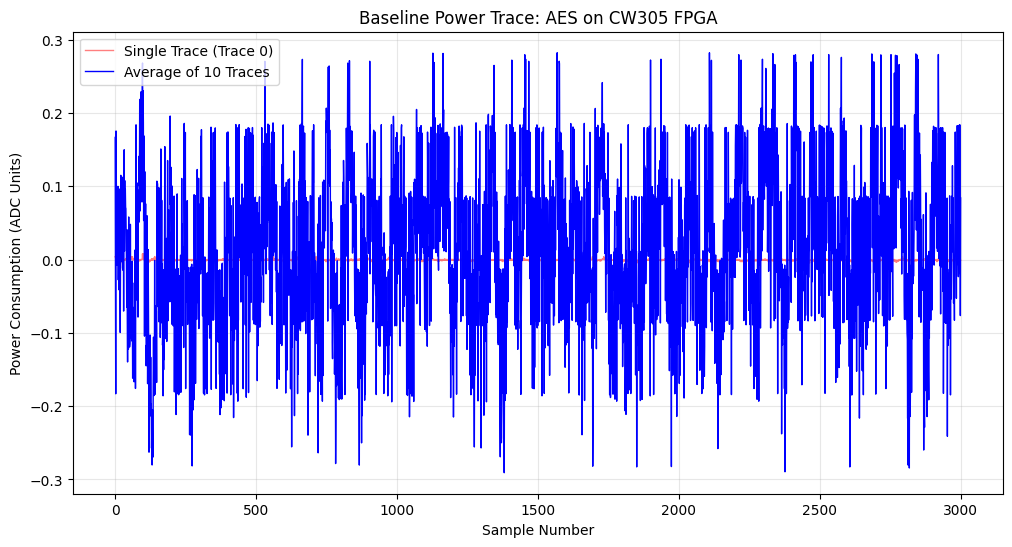

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [16]:
VCC_INT_TARGET = 0.88 # Lower VCC-INT (e.g., 0.75V) makes the FPGA more susceptible to glitches
## --- 3. GLITCH ATTACK LOOP ---
# Range of glitch widths (e.g., 5.0% to 40.0% of clock cycle)
WIDTH_MIN = 5.0
WIDTH_MAX = 40.0

# Range of glitch offsets (timing shift relative to the trigger, e.g., -40.0% to +40.0%)
OFFSET_MIN = -40.0
OFFSET_MAX = 40.0

print("\n--- Starting Glitch Attack Loop (Sweeping Parameters) ---")
glitched_results = []
successful_faults = 0
successful_params = []
for i in range(NUM_GLITCH_ATTEMPTS):
    
    #  NEW: Select random parameters for this attempt 
    current_width = np.random.uniform(WIDTH_MIN, WIDTH_MAX)
    current_offset = np.random.uniform(OFFSET_MIN, OFFSET_MAX)
    
    scope.glitch.width = current_width
    scope.glitch.offset = current_offset
    
    # Reset target power briefly before each glitch attempt...
    #target.vccint_set(1.0) 
    #time.sleep(0.05)
    target.vccint_set(VCC_INT_TARGET)
    #time.sleep(0.05)
    # The VCC-INT setting of 0.69V might be causing problems or is too low.
    # A simple target.reset_target() is often safer, but keep the VCC cycling for now.
    
    
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        # ... timeout handling ...
        glitched_results.append({'trace': None, 'output': 'TIMEOUT', 'attempt': i})
        print(f"Attempt {i}: TIMEOUT (Probable FPGA corruption)")
        continue
    
    trace = scope.get_last_trace()

    if output.hex() == EXPECTED_CIPHERTEXT.hex():
        result = 'NORMAL'
    else:
        result = 'FAULT'
        successful_faults += 1
        # NEW: Log successful parameters 
        successful_params.append({
            'width': current_width, 
            'offset': current_offset, 
            'output': output.hex(),
            'attempt': i
        })
        
    glitched_results.append({'trace': trace, 'output': output.hex() if output else result, 'attempt': i, 'result': result})
    print(f"Attempt {i}: Result: {result}, W: {current_width:.2f}, O: {current_offset:.2f}, Output: {output.hex()}")


# --- NEW: Add a final printout of successful settings ---
print("\n--- Successful Glitch Parameters ---")
for p in successful_params:
    print(f"Attempt {p['attempt']} - Width: {p['width']:.2f}, Offset: {p['offset']:.2f}, Output: {p['output']}")


--- Starting Glitch Attack Loop (Sweeping Parameters) ---
Attempt 0: Result: NORMAL, W: 20.06, O: 19.83, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 1: Result: NORMAL, W: 23.31, O: -6.40, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 2: Result: NORMAL, W: 36.25, O: 8.58, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 3: Result: NORMAL, W: 28.09, O: 12.50, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 4: Result: NORMAL, W: 18.51, O: -22.61, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 5: Result: NORMAL, W: 5.91, O: -22.13, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 6: Result: NORMAL, W: 16.07, O: -12.40, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 7: Result: NORMAL, W: 16.58, O: -14.64, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 8: Result: NORMAL, W: 23.54, O: -1.80, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 9: Result: NORMAL, W: 27.63, O: -21.16, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 10: Result: NORMAL, W: 33.00, O: -28.51, Output: 0

(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work


Attempt 36: Result: NORMAL, W: 12.47, O: -13.14, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 37: Result: NORMAL, W: 23.30, O: -9.64, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 38: Result: NORMAL, W: 20.13, O: 35.60, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 39: Result: NORMAL, W: 37.20, O: -32.43, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 40: Result: NORMAL, W: 16.34, O: -3.62, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 41: Result: NORMAL, W: 11.26, O: -5.96, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 42: Result: NORMAL, W: 12.04, O: -22.41, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 43: Result: NORMAL, W: 39.37, O: 0.12, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 44: Result: NORMAL, W: 20.25, O: 18.18, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 45: Result: NORMAL, W: 7.70, O: -9.04, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 46: Result: NORMAL, W: 38.05, O: -10.41, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 47: Result:

(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work


Attempt 192: Result: NORMAL, W: 5.42, O: 23.21, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 193: Result: NORMAL, W: 28.67, O: 6.74, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 194: Result: NORMAL, W: 29.27, O: 3.63, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 195: Result: NORMAL, W: 17.03, O: 4.48, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 196: Result: NORMAL, W: 8.59, O: -29.54, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 197: Result: NORMAL, W: 13.60, O: -35.54, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 198: Result: NORMAL, W: 23.32, O: -4.21, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 199: Result: NORMAL, W: 7.02, O: 4.02, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 200: Result: NORMAL, W: 38.54, O: -11.22, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 201: Result: NORMAL, W: 9.08, O: -0.15, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 202: Result: NORMAL, W: 31.55, O: -1.70, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 203: Re

(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work


Attempt 398: Result: NORMAL, W: 36.64, O: 33.89, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 399: Result: NORMAL, W: 26.35, O: 11.39, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 400: Result: NORMAL, W: 8.27, O: -7.42, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 401: Result: NORMAL, W: 17.18, O: 34.53, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 402: Result: NORMAL, W: 7.91, O: -39.08, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 403: Result: NORMAL, W: 27.60, O: -0.05, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 404: Result: NORMAL, W: 25.80, O: -22.20, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 405: Result: NORMAL, W: 24.02, O: 23.29, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 406: Result: NORMAL, W: 19.97, O: 16.59, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 407: Result: NORMAL, W: 32.64, O: -29.91, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 408: Result: NORMAL, W: 21.85, O: -30.81, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 

In [12]:
glitched_results = []
successful_faults = 0
successful_params = []
# --- VCC_INT SWEEP DEFINITION ---
# Start safe (0.85V) and go down to crash point (0.70V), in 20 steps
VCC_INT_TARGET = 1.0
VCC_SWEEP = np.linspace(1.0, 0.70, 10) 

# --- OFFSET SWEEP DEFINITION ---
OFFSETS = np.linspace(-40.0, 40.0, 80) 
FIXED_WIDTH = 4.0 
ATTEMPTS_PER_POINT = 1

print("\n--- Starting Nested VCC/Offset Sweep ---")

for vcc in VCC_SWEEP:
    # 1. SET THE NEW VULNERABLE VOLTAGE
    target.vccint_set(vcc)
    scope.glitch.width = FIXED_WIDTH
    
    # 2. SWEEP OFFSET AT THIS VOLTAGE LEVEL
    for offset in OFFSETS:
        scope.glitch.offset = offset
        
        # 3. ATTEMPT GLITCH MULTIPLE TIMES
        for attempt in range(ATTEMPTS_PER_POINT):
            
            i = len(glitched_results) # Tracking total attempts
            
            scope.arm()
            output, success = run_aes(target, PLAINTEXT, KEY)

            # --- CRASH & REPROGRAM LOGIC ---
            if scope.capture():
                # Handle timeout/crash
                try:
                    target.fpga_write(BITSTREAM_FILEPATH)
                except:
                    pass
                # Log the crash for plotting later
                glitched_results.append({'result': 'TIMEOUT', 'vcc': vcc, 'offset': offset}) 
                continue
            
            # --- FAULT DETECTION LOGIC ---
            output_hex = output.hex() if output else "N/A"
            expected_hex = EXPECTED_CIPHERTEXT.hex() 
            
            if output_hex != expected_hex:
                result = 'FAULT'
                successful_faults += 1
            else:
                result = 'NORMAL'
                print(f"Attempt {i}: **Normal** (VCC={vcc:.2f}, o={offset:.1f})")

            # Log the result
            glitched_results.append({'result': result, 'vcc': vcc, 'offset': offset, 'output': output_hex})
            
            if result == 'FAULT':
                print(f"Attempt {i}: **FAULT** (VCC={vcc:.2f}, o={offset:.1f})")


--- Starting Nested VCC/Offset Sweep ---
Attempt 0: **Normal** (VCC=1.00, o=-40.0)
Attempt 1: **Normal** (VCC=1.00, o=-39.0)
Attempt 2: **Normal** (VCC=1.00, o=-38.0)
Attempt 3: **Normal** (VCC=1.00, o=-37.0)
Attempt 4: **Normal** (VCC=1.00, o=-35.9)
Attempt 5: **Normal** (VCC=1.00, o=-34.9)
Attempt 6: **Normal** (VCC=1.00, o=-33.9)
Attempt 7: **Normal** (VCC=1.00, o=-32.9)
Attempt 8: **Normal** (VCC=1.00, o=-31.9)
Attempt 9: **Normal** (VCC=1.00, o=-30.9)
Attempt 10: **Normal** (VCC=1.00, o=-29.9)
Attempt 11: **Normal** (VCC=1.00, o=-28.9)
Attempt 12: **Normal** (VCC=1.00, o=-27.8)
Attempt 13: **Normal** (VCC=1.00, o=-26.8)
Attempt 14: **Normal** (VCC=1.00, o=-25.8)
Attempt 15: **Normal** (VCC=1.00, o=-24.8)
Attempt 16: **Normal** (VCC=1.00, o=-23.8)
Attempt 17: **Normal** (VCC=1.00, o=-22.8)
Attempt 18: **Normal** (VCC=1.00, o=-21.8)
Attempt 19: **Normal** (VCC=1.00, o=-20.8)
Attempt 20: **Normal** (VCC=1.00, o=-19.7)
Attempt 21: **Normal** (VCC=1.00, o=-18.7)
Attempt 22: **Normal**

In [17]:
glitched_results = []
successful_faults = 0
successful_params = []
# --- VCC_INT SWEEP DEFINITION ---
# Start safe (1.0V) and go down to crash point (0.70V), in 10 steps
VCC_INT_TARGET = 0.9
VCC_SWEEP = np.linspace(0.9, 0.70, 10)  # VCC_SWEEP range from 1.0V to 0.70V

# --- OFFSET SWEEP DEFINITION ---
OFFSETS = np.linspace(-40.0, 40.0, 80)
FIXED_WIDTH = 40
ATTEMPTS_PER_POINT = 1

print("\n--- Starting Nested VCC/Offset Sweep ---")
print(f"Total Attempts: {len(VCC_SWEEP) * len(OFFSETS) * ATTEMPTS_PER_POINT}")


for vcc in VCC_SWEEP:
    # 1. SET THE NEW VULNERABLE VOLTAGE
    target.vccint_set(vcc)
    scope.glitch.width = FIXED_WIDTH
    
    # 2. SWEEP OFFSET AT THIS VOLTAGE LEVEL
    for offset in OFFSETS:
        scope.glitch.offset = offset
        
        # 3. ATTEMPT GLITCH MULTIPLE TIMES
        for attempt in range(ATTEMPTS_PER_POINT):
            
            i = len(glitched_results) # Tracking total attempts
            
            scope.arm()
            output, success = run_aes(target, PLAINTEXT, KEY)

            # --- CRASH & REPROGRAM LOGIC ---
            if scope.capture():
                # Handle timeout/crash
                try:
                    target.fpga_write(BITSTREAM_FILEPATH)
                except:
                    pass
                # Log the crash for plotting later
                glitched_results.append({'result': 'TIMEOUT', 'vcc': vcc, 'offset': offset})
                print(f"Attempt {i}: TIMEOUT (VCC={vcc:.2f}, o={offset:.1f}). Reprogrammed.")
                continue
            
            # --- FAULT DETECTION LOGIC ---
            output_hex = output.hex() if output else "N/A"
            expected_hex = EXPECTED_CIPHERTEXT.hex()
            
            if output_hex != expected_hex:
                result = 'FAULT'
                successful_faults += 1
            else:
                result = 'NORMAL'
                
            # Log the result
            glitched_results.append({'result': result, 'vcc': vcc, 'offset': offset, 'output': output_hex})
            
            # --- MODIFIED PRINT STATEMENT TO SHOW OUTPUT ---
            if result == 'FAULT':
                print(f"Attempt {i}: **FAULT** (VCC={vcc:.2f}, o={offset:.1f}) OUTPUT: {output_hex}")
                successful_params.append({'vcc': vcc, 'offset': offset, 'output': output_hex})
            else:
                # Prints the correct output for monitoring
                print(f"Attempt {i}: Normal (VCC={vcc:.2f}, o={offset:.1f}) OUTPUT: {output_hex}")


--- Starting Nested VCC/Offset Sweep ---
Total Attempts: 800
Attempt 0: Normal (VCC=0.90, o=-40.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 1: Normal (VCC=0.90, o=-39.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 2: Normal (VCC=0.90, o=-38.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 3: Normal (VCC=0.90, o=-37.0) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 4: Normal (VCC=0.90, o=-35.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 5: Normal (VCC=0.90, o=-34.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 6: Normal (VCC=0.90, o=-33.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 7: Normal (VCC=0.90, o=-32.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 8: Normal (VCC=0.90, o=-31.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 9: Normal (VCC=0.90, o=-30.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 10: Normal (VCC=0.90, o=-29.9) OUTPUT: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 11: Normal (VCC=0.90, o=-28.9) OUTPUT: 06f36a65e8a99ff8907b2

In [15]:
# --- NEW ATTACK PARAMETER RANGES ---
# Attack Parameters

# List to store successful parameters
successful_params = []
## --- 3. GLITCH ATTACK LOOP ---
print("\n--- Starting Glitch Attack Loop ---")
glitched_results = []
successful_faults = 0

# Adjust glitch parameters if you are sweeping a range
# E.g., for sweeping:
# scope.glitch.width = np.random.uniform(5.0, 30.0) 
# scope.glitch.offset = np.random.uniform(-40.0, 40.0)

for i in range(NUM_GLITCH_ATTEMPTS):
    
    # Reset target power briefly before each glitch attempt to clear potential config corruption
    target.vccint_set(VCC_INT_TARGET)
    #time.sleep(0.00005)
    #target.vccint_set(0.69)
    #time.sleep(0.05)
    
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        # A timeout usually means the FPGA configuration was corrupted and reset
        glitched_results.append({'trace': None, 'output': 'TIMEOUT', 'attempt': i})
        print(f"Attempt {i}: TIMEOUT (Probable FPGA corruption)")
        
        # You may need to reprogram the FPGA here if the timeout persists
        # target.fpga_write(BITSTREAM_FILEPATH)
        continue
    
    trace = scope.get_last_trace()

    if output.hex() == EXPECTED_CIPHERTEXT.hex():
        result = 'NORMAL'
    else:
        result = 'FAULT'
        successful_faults += 1
        
    glitched_results.append({'trace': trace, 'output': output.hex() if output else result, 'attempt': i, 'result': result})
    print(f"Attempt {i}: Result: {result}, Output: {output.hex()}")
#if output and result != 'NORMAL' else 'Correct'}
print(f"\n--- ATTACK SUMMARY ---")
print(f"Total Attempts: {NUM_GLITCH_ATTEMPTS}")
print(f"Successful Faults Found: {successful_faults}")


--- Starting Glitch Attack Loop ---
Attempt 0: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd55dc
Attempt 1: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd54dc
Attempt 2: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd54dc
Attempt 3: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd55dc
Attempt 4: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd55dc
Attempt 5: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd55dc
Attempt 6: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd54dc
Attempt 7: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd55dc
Attempt 8: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd55dc
Attempt 9: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd55dc
Attempt 10: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd55dc
Attempt 11: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd54dc
Attempt 12: Result: FAULT, Output: 04d14845c8899cd890590c5c5ddd55dc
Attempt 13: Result: FAULT, Output: 04d14845c8899dd890590c5c5ddd55dc
Attempt 14: Result: F

In [ ]:
if not success or output is None:
        result = 'COMM_FAIL'
    elif output.hex() != EXPECTED_CIPHERTEXT:
        result = 'FAULT'
        successful_faults += 1
    else:
        result = 'NORMAL'